# Distance-based trilateration from Hamming distances

This notebook keeps the same three references as anchors but solves an approximate trilateration problem in the plane. It tries to match actual distance magnitudes rather than only relative similarity proportions. The anchor geometry can in principle be driven by other distances too, including normalized alignment distances.

## Inputs

All notebooks use the same FASTA inputs bundled in `sequenceTols`: `example_vertices.fasta` for the three references and `example_queries.fasta` for the query sequences. You can replace those paths in the first code cell with your own FASTA files.

In [1]:
from pathlib import Path
import csv
import math
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

REFERENCES_FASTA = Path("example_vertices.fasta")
QUERIES_FASTA = Path("example_queries.fasta")
OUTPUT_PREFIX = Path("notebook_output")


def parse_fasta(path: Path):
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(chunks).upper()))
                header = line[1:].strip() or f"seq_{len(records) + 1}"
                chunks = []
            else:
                chunks.append(line)
    if header is not None:
        records.append((header, "".join(chunks).upper()))
    if not records:
        raise ValueError(f"No FASTA records found in {path}")
    return records


def normalized_hamming(seq_a: str, seq_b: str) -> float:
    if len(seq_a) != len(seq_b):
        raise ValueError("Hamming distance requires equal-length sequences.")
    if len(seq_a) == 0:
        return 0.0
    mismatches = sum(char_a != char_b for char_a, char_b in zip(seq_a, seq_b))
    return mismatches / len(seq_a)


def levenshtein_distance(seq_a: str, seq_b: str) -> int:
    if len(seq_a) < len(seq_b):
        seq_a, seq_b = seq_b, seq_a
    previous = list(range(len(seq_b) + 1))
    for i, char_a in enumerate(seq_a, start=1):
        current = [i]
        for j, char_b in enumerate(seq_b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            substitute_cost = previous[j - 1] + (char_a != char_b)
            current.append(min(insert_cost, delete_cost, substitute_cost))
        previous = current
    return previous[-1]


def normalized_levenshtein(seq_a: str, seq_b: str) -> float:
    scale = max(len(seq_a), len(seq_b))
    if scale == 0:
        return 0.0
    return levenshtein_distance(seq_a, seq_b) / scale


def affinity_linear(distance: float) -> float:
    return max(0.0, 1.0 - distance)


def close_affinities(affinities):
    affinities = np.asarray(affinities, dtype=float)
    total = float(affinities.sum())
    if total <= 0.0:
        return np.full(3, 1.0 / 3.0)
    return affinities / total


def barycentric_to_cartesian(lambdas):
    vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, math.sqrt(3.0) / 2.0],
    ])
    return np.asarray(lambdas, dtype=float) @ vertices


def write_csv(path: Path, rows, fieldnames):
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def trilaterate(reference_xy, distances):
    p1 = np.asarray(reference_xy[0], dtype=float)
    p2 = np.asarray(reference_xy[1], dtype=float)
    p3 = np.asarray(reference_xy[2], dtype=float)
    d1, d2, d3 = [float(value) for value in distances]
    matrix = 2.0 * np.array([
        [p2[0] - p1[0], p2[1] - p1[1]],
        [p3[0] - p1[0], p3[1] - p1[1]],
    ])
    rhs = np.array([
        d1 ** 2 - d2 ** 2 + np.dot(p2, p2) - np.dot(p1, p1),
        d1 ** 2 - d3 ** 2 + np.dot(p3, p3) - np.dot(p1, p1),
    ])
    solution, _, _, _ = np.linalg.lstsq(matrix, rhs, rcond=None)
    residuals = np.array([abs(np.linalg.norm(solution - point) - dist) for point, dist in zip(reference_xy, distances)])
    return solution, residuals


## Mathematical formulation

Here the three references are treated as fixed geometric anchors in the plane:
\[
V_A=(0,0),\qquad V_B=(1,0),\qquad V_C=\left(\frac12,\frac{\sqrt3}{2}\right).
\]
For each query $Q$, the notebook computes the normalized Hamming distances
\[
d_A(Q),\qquad d_B(Q),\qquad d_C(Q),
\]
and then looks for a point $\mathbf{z}(Q)\in\mathbb{R}^2$ such that
\[
\|\mathbf{z}(Q)-V_A\|_2\approx d_A(Q),\qquad
\|\mathbf{z}(Q)-V_B\|_2\approx d_B(Q),\qquad
\|\mathbf{z}(Q)-V_C\|_2\approx d_C(Q).
\]
Starting from the squared-distance equations and subtracting the equation for $A$ from those for $B$ and $C$, one obtains the linear system
\[
2(V_B-V_A)^\top \mathbf{z}=d_A^2-d_B^2+\|V_B\|_2^2-\|V_A\|_2^2,
\]
\[
2(V_C-V_A)^\top \mathbf{z}=d_A^2-d_C^2+\|V_C\|_2^2-\|V_A\|_2^2.
\]
This is solved by least squares. The notebook also reports residuals
\[
\rho_i(Q)=\big|\|\mathbf{z}(Q)-V_i\|_2-d_i(Q)\big|,
\]
which quantify how inconsistent the three sequence distances are with the chosen 2D anchor geometry.

## Interpretation and limitations

This notebook is mathematically closer to a true distance-based embedding than the ternary notebooks, because it tries to preserve actual distance magnitudes.

Still, it has limits:

- the embedding is constrained by the fixed anchor triangle,
- inconsistent distance triples necessarily generate residuals,
- points may fall outside the triangle,
- the method is still not a phylogenetic reconstruction,
- if the sequence dissimilarity itself is too crude, for example Hamming distance on proteins, the geometric reconstruction inherits that weakness.

So the correct reading is: *which 2D point best matches the three measured distances to the anchors?*

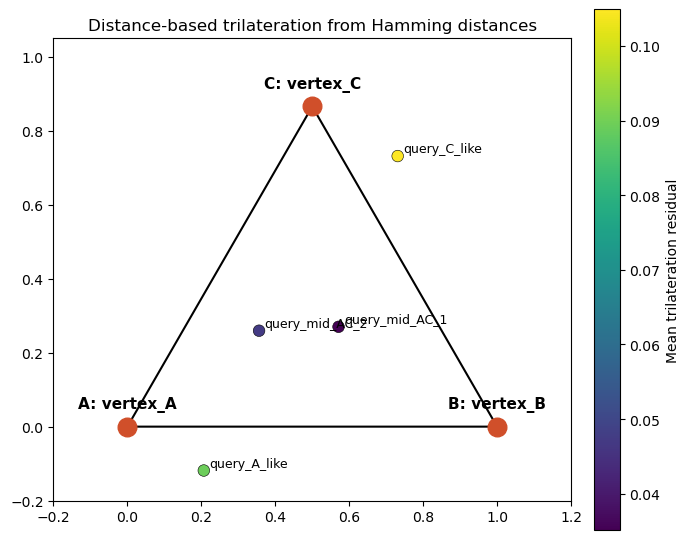

Saved CSV: notebook_output_trilateration_coordinates.csv
Saved plot: notebook_output_trilateration.png
[{'distance_to_A': 0.03333333333333333,
  'distance_to_B': 0.7666666666666667,
  'distance_to_C': 1.0,
  'mean_residual': 0.08931464836764057,
  'residual_A': 0.204984675325326,
  'residual_B': 0.035494252300154794,
  'residual_C': 0.0274650174774409,
  'sequence_id': 'query_A_like',
  'x': 0.20666666666666667,
  'y': -0.11867755533342311},
 {'distance_to_A': 0.6,
  'distance_to_B': 0.4666666666666667,
  'distance_to_C': 0.5666666666666667,
  'mean_residual': 0.03514483050229563,
  'residual_A': 0.031748830123285776,
  'residual_B': 0.040170942573134805,
  'residual_C': 0.033514718810466304,
  'sequence_id': 'query_mid_AC_1',
  'x': 0.5711111111111112,
  'y': 0.27007162592092504},
 {'distance_to_A': 0.5,
  'distance_to_B': 0.7333333333333333,
  'distance_to_C': 0.6666666666666666,
  'mean_residual': 0.04726521621252842,
  'residual_A': 0.059377077683443746,
  'residual_B': 0.039124188

In [2]:
reference_records = parse_fasta(REFERENCES_FASTA)
query_records = parse_fasta(QUERIES_FASTA)
assert len(reference_records) == 3, "The references FASTA must contain exactly 3 sequences."

reference_ids = [record[0] for record in reference_records]
reference_sequences = [record[1] for record in reference_records]
reference_xy = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, math.sqrt(3.0) / 2.0],
])
rows = []

for query_id, query_sequence in query_records:
    distances = np.array([
        normalized_hamming(query_sequence, ref_sequence)
        for ref_sequence in reference_sequences
    ], dtype=float)
    xy, residuals = trilaterate(reference_xy, distances)
    rows.append({
        "sequence_id": query_id,
        "distance_to_A": float(distances[0]),
        "distance_to_B": float(distances[1]),
        "distance_to_C": float(distances[2]),
        "x": float(xy[0]),
        "y": float(xy[1]),
        "residual_A": float(residuals[0]),
        "residual_B": float(residuals[1]),
        "residual_C": float(residuals[2]),
        "mean_residual": float(residuals.mean()),
    })

fieldnames = list(rows[0].keys())
output_csv = Path(f"{OUTPUT_PREFIX.name}_trilateration_coordinates.csv")
write_csv(output_csv, rows, fieldnames)

fig, ax = plt.subplots(figsize=(7, 7))
triangle = np.vstack((reference_xy, reference_xy[0]))
ax.plot(triangle[:, 0], triangle[:, 1], color="black", linewidth=1.5)
ax.scatter(reference_xy[:, 0], reference_xy[:, 1], s=180, color="#d04f2a", zorder=3)
query_xy = np.array([[row["x"], row["y"]] for row in rows], dtype=float)
residual_color = np.array([row["mean_residual"] for row in rows], dtype=float)
scatter = ax.scatter(query_xy[:, 0], query_xy[:, 1], c=residual_color, cmap="viridis", s=70, edgecolor="black", linewidth=0.4, zorder=3)

for label, (x_coord, y_coord) in zip([f"A: {reference_ids[0]}", f"B: {reference_ids[1]}", f"C: {reference_ids[2]}"], reference_xy):
    ax.text(x_coord, y_coord + 0.04, label, ha="center", va="bottom", fontsize=11, fontweight="bold")

for row in rows:
    ax.text(row["x"] + 0.015, row["y"] + 0.01, row["sequence_id"], fontsize=9)

fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label="Mean trilateration residual")
ax.set_title("Distance-based trilateration from Hamming distances")
ax.set_aspect("equal")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.05)
fig.tight_layout()
output_png = Path(f"{OUTPUT_PREFIX.name}_trilateration.png")
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved CSV: {output_csv}")
print(f"Saved plot: {output_png}")
pprint(rows)
